# 01 — Pallet Build & Master Data Checks

**Question:** Is the client's product master usable, and how big is each product's pallet?

Every later calculation — storage volume, pallet positions, racking design — depends on carton dimensions and pallet builds. Errors here flow through everything downstream, so the master data is checked first.

**Pallet standard:** 120 × 100 cm footprint, 15 cm deck, 25 kg tare.
**Rack limit:** 750 kg per pallet position (temperature-controlled chamber rating).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA, OUT = Path("../data"), Path("../outputs")
OUT.mkdir(exist_ok=True)

PALLET_L, PALLET_W = 120, 100   # cm
PALLET_DECK = 15                # cm
PALLET_TARE = 25                # kg
RACK_LIMIT_KG = 750             # kg per position

sku = pd.read_csv(DATA / "sku_master.csv")
print(f"{len(sku)} SKUs from {sku.principal.nunique()} principals")
sku.head()

600 SKUs from 13 principals


,sku,description,principal,category,product_group,storage_condition,units_per_case,case_length_cm,case_width_cm,case_height_cm,case_cbm,case_weight_kg,unit_cost_nzd,ti_cases_per_layer,hi_layers
0,PH10001,Sertraline 100mg Tablets 100s,Venrick Laboratories,Pharma,Tablets,Below 25C,120,59.6,35.1,23.8,0.04979,8.97,13.84,4,6
1,PH10002,Pantoprazole 40mg Tablets 30s,Corvane Pharma,Pharma,Tablets,Below 25C,120,30.5,42.5,25.8,0.03344,8.72,11.92,6,5
2,PH10003,Ibuprofen 200mg Tablets 30s,Halvora Healthcare,Pharma,Tablets,Below 25C,240,47.7,25.2,17.2,0.02068,5.45,5.93,15,5
3,PH10004,Azithromycin 250mg Tablets 10x10,Arcadine Pharma,Pharma,Tablets,Below 25C,100,33.5,38.9,32.8,0.04274,9.76,19.81,4,2
4,PH10005,Rosuvastatin 10mg Tablets 2x14,Halvora Healthcare,Pharma,Tablets,Below 25C,240,42.5,32.1,33.2,0.04529,10.17,4.58,6,2


## 1. Master data checks

Five checks. Each one catches a type of error that is common in real client data:

| Check | Why it matters |
|---|---|
| Missing dimension | Can't calculate volume or pallet height |
| Missing weight | Can't check the rack load limit |
| CBM mismatch | Stated carton volume disagrees with L × W × H — usually a decimal slip |
| Impossible Ti | Supplier claims more cases per layer than physically fit on the pallet |
| Missing Hi | Can't calculate pallet height or pallet quantity |

In [2]:
# Maximum cases per layer that physically fit (best of two orientations)
def max_ti(l, w):
    if l <= 0 or w <= 0:
        return 0
    return int(max((PALLET_L // l) * (PALLET_W // w), (PALLET_L // w) * (PALLET_W // l)))

sku["ti_physical_max"] = [max_ti(l, w) for l, w in zip(sku.case_length_cm, sku.case_width_cm)]
sku["cbm_calculated"] = sku.case_length_cm * sku.case_width_cm * sku.case_height_cm / 1e6

dims_missing = (sku[["case_length_cm", "case_width_cm", "case_height_cm"]] == 0).any(axis=1)

checks = {
    "missing_dimension": dims_missing,
    "missing_weight":    sku.case_weight_kg == 0,
    "cbm_mismatch":      ~dims_missing & ((sku.case_cbm / sku.cbm_calculated - 1).abs() > 0.05),
    "impossible_ti":     sku.ti_cases_per_layer > sku.ti_physical_max,
    "missing_hi":        sku.hi_layers == 0,
}
for name, flag in checks.items():
    sku[name] = flag

sku["issue_count"] = sku[list(checks)].sum(axis=1)
pd.Series({k: v.sum() for k, v in checks.items()}, name="SKUs affected").to_frame()

,SKUs affected
missing_dimension,6
missing_weight,6
cbm_mismatch,6
impossible_ti,6
missing_hi,6


## 2. Resolve what we can

Not every error needs to go back to the client. Some can be fixed from data we already have:

- **CBM mismatch** → recalculate from L × W × H
- **Impossible Ti** → cap at the physical maximum
- **Missing Hi** → estimate layers for a 130 cm stack, capped by weight

Missing dimensions and weights **cannot** be fixed internally — they need a physical measurement, so they go back to the client.

In [3]:
sku["case_cbm_clean"] = np.where(sku.cbm_mismatch, sku.cbm_calculated, sku.case_cbm)
sku["ti_clean"] = np.minimum(sku.ti_cases_per_layer, sku.ti_physical_max)

est_hi = np.floor(130 / sku.case_height_cm.replace(0, np.nan))
sku["hi_clean"] = np.where(sku.missing_hi, est_hi, sku.hi_layers)

sku["resolution"] = np.select(
    [sku.missing_dimension | sku.missing_weight,
     sku.issue_count > 0],
    ["Needs client data", "Fixed internally"],
    default="OK",
)
sku.resolution.value_counts()

resolution
OK                   570
Fixed internally      18
Needs client data     12
Name: count, dtype: int64

## 3. Pallet build

For every SKU with usable data:

- **Pallet height** = deck + layers × case height
- **Pallet weight** = cases × case weight + pallet tare
- **Pallet CBM** = cases × case volume
- **Footprint use** = how much of the 120 × 100 cm deck the cartons actually cover

In [4]:
ok = sku[sku.resolution != "Needs client data"].copy()
ok["hi_clean"] = ok.hi_clean.astype(int)

ok["cases_per_pallet"] = ok.ti_clean * ok.hi_clean
ok["units_per_pallet"] = ok.cases_per_pallet * ok.units_per_case
ok["pallet_height_cm"] = PALLET_DECK + ok.hi_clean * ok.case_height_cm
ok["pallet_weight_kg"] = ok.cases_per_pallet * ok.case_weight_kg + PALLET_TARE
ok["pallet_cbm"] = ok.cases_per_pallet * ok.case_cbm_clean
ok["footprint_use"] = ok.ti_clean * ok.case_length_cm * ok.case_width_cm / (PALLET_L * PALLET_W)

ok[["pallet_height_cm", "pallet_weight_kg", "pallet_cbm", "footprint_use"]].describe().round(2)

,pallet_height_cm,pallet_weight_kg,pallet_cbm,footprint_use
count,588.00,588.00,588.00,588.00
mean,114.50,271.45,0.87,0.73
std,27.08,184.46,0.28,0.13
min,53.40,49.12,0.22,0.30
25%,93.88,157.54,0.65,0.66
50%,114.90,220.06,0.87,0.74
75%,138.28,303.61,1.06,0.82
max,165.00,1021.24,1.62,1.00


## 4. Rack load check

Supplier pallets can weigh up to 1,000 kg, but the temperature-controlled racking is rated at 750 kg per position. Overweight pallets have to be broken down to fewer layers on receipt — extra handling and extra positions.

In [5]:
over = ok.pallet_weight_kg > RACK_LIMIT_KG
max_hi_rack = np.floor((RACK_LIMIT_KG - PALLET_TARE) / (ok.ti_clean * ok.case_weight_kg)).astype(int)
ok["hi_rack"] = np.where(over, max_hi_rack, ok.hi_clean)

print(f"Pallets over {RACK_LIMIT_KG} kg: {over.sum()}")
ok.loc[over, ["sku", "description", "product_group", "hi_clean", "hi_rack", "pallet_weight_kg"]] \
  .sort_values("pallet_weight_kg", ascending=False).head(10)

Pallets over 750 kg: 31


,sku,description,product_group,hi_clean,hi_rack,pallet_weight_kg
389,PH10390,Compound Sodium Lactate IV 500ml Bag,IV Fluids,4,2,1021.24
383,PH10384,Compound Sodium Lactate IV 250ml Bag,IV Fluids,5,3,1003.20
358,PH10359,Salbutamol 2mg/5ml Syrup 60ml,Syrups,8,6,980.44
394,PH10395,Dextrose 5% IV 250ml Bag,IV Fluids,3,2,965.32
375,PH10376,Sodium Chloride 0.9% IV 1000ml Bottle,IV Fluids,5,3,958.00
393,PH10394,Dextrose 10% IV 500ml Bag,IV Fluids,4,3,956.92
363,PH10364,Loratadine 5mg/5ml Syrup 60ml,Syrups,8,6,952.36
392,PH10393,Dextrose 5% IV 500ml Bottle,IV Fluids,4,3,927.40
370,PH10371,Glucose 4% + NaCl 0.18% IV 250ml Bag,IV Fluids,6,4,924.76
341,PH10342,Ibuprofen 100mg/5ml Suspension 60ml,Syrups,7,5,915.96


## 5. Pallet height profile

This chart sets up the rack reconfiguration in Notebook 4. If every beam opening is built for the tallest pallet, every shorter pallet stores air above it.

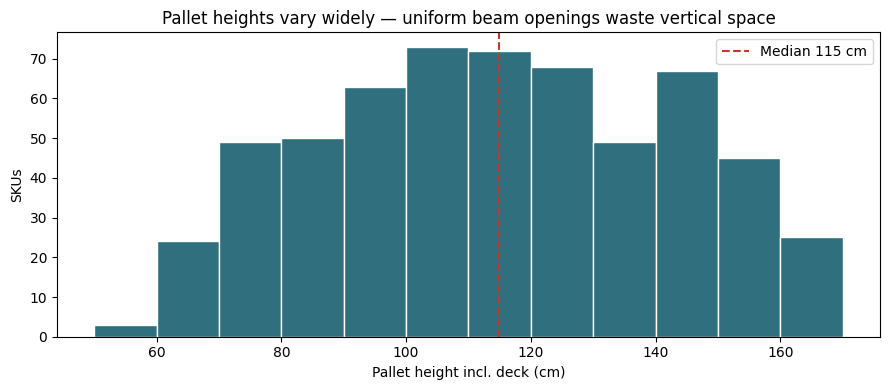

,SKUs
pallet_height_cm,
"(0, 80]",76
"(80, 100]",114
"(100, 120]",146
"(120, 140]",115
"(140, 180]",137


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ok.pallet_height_cm, bins=range(50, 180, 10), color="#2f6f7e", edgecolor="white")
ax.axvline(ok.pallet_height_cm.median(), color="#c0392b", ls="--",
           label=f"Median {ok.pallet_height_cm.median():.0f} cm")
ax.set(title="Pallet heights vary widely — uniform beam openings waste vertical space",
       xlabel="Pallet height incl. deck (cm)", ylabel="SKUs")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "01_pallet_height_profile.png", dpi=150)
plt.show()

bands = pd.cut(ok.pallet_height_cm, [0, 80, 100, 120, 140, 180])
bands.value_counts().sort_index().to_frame("SKUs")

## 6. Issues report for the client

The output a real mobilisation team sends back: every SKU that needs attention, grouped by principal, with what's wrong and whether it's already been handled.

In [7]:
issue_cols = list(checks)
report = sku[sku.issue_count > 0][["principal", "sku", "description", "resolution"] + issue_cols].copy()
report["issues"] = report[issue_cols].apply(lambda r: ", ".join(c.replace("_", " ") for c in issue_cols if r[c]), axis=1)
report = report.drop(columns=issue_cols).sort_values(["resolution", "principal"])

by_principal = report.groupby(["principal", "resolution"]).size().unstack(fill_value=0)

with pd.ExcelWriter(OUT / "01_master_data_issues.xlsx") as xl:
    report.to_excel(xl, sheet_name="Issues by SKU", index=False)
    by_principal.to_excel(xl, sheet_name="By principal")

by_principal

resolution,Fixed internally,Needs client data
principal,,
Aldermoor Medical,2,0
Arcadine Pharma,0,1
Corvane Pharma,2,0
Dunmore Therapeutics,1,0
Halvora Healthcare,4,1
Kinloch Nutrition,1,0
Marwick Pharmaceuticals,5,2
Pellaro Eye & Skin,2,2
Quintessa Diagnostics,0,1


## 7. Save for the next notebook

In [8]:
cols = ["sku", "description", "principal", "category", "product_group", "storage_condition",
        "units_per_case", "case_length_cm", "case_width_cm", "case_height_cm", "case_cbm_clean",
        "case_weight_kg", "unit_cost_nzd", "ti_clean", "hi_rack", "cases_per_pallet",
        "pallet_height_cm", "pallet_weight_kg", "pallet_cbm"]

pallet = ok[cols].rename(columns={"case_cbm_clean": "case_cbm", "ti_clean": "ti", "hi_rack": "hi"})
pallet["cases_per_pallet"] = pallet.ti * pallet.hi
pallet["pallet_height_cm"] = PALLET_DECK + pallet.hi * pallet.case_height_cm
pallet["pallet_cbm"] = pallet.cases_per_pallet * pallet.case_cbm
pallet.to_csv(DATA / "pallet_build.csv", index=False)
print(f"Saved pallet_build.csv — {len(pallet)} SKUs ready for storage analysis")

Saved pallet_build.csv — 588 SKUs ready for storage analysis


## Findings

- **30 of 600 SKUs (5%) had master data errors.** 18 were resolved internally; 12 need measurements from the client before they can be stored accurately.
- **Pallet heights range from under 60 cm to over 160 cm.** A single uniform beam height cannot suit this range — the case for the reconfiguration in Notebook 4.
- **31 pallets exceed the 750 kg rack limit** — almost all IV fluids and syrups. They must be rebuilt to fewer layers on receipt, which increases the number of positions they occupy.